
# Credit Card Fraud EDA and Model Diagnostics

This notebook covers:
- Dataset profiling and fraud imbalance
- Univariate and bivariate visual analysis
- Correlation analysis
- Model diagnostics using saved `model.pkl`
- ROC curve, Precision-Recall curve
- Threshold vs cost analysis from `data/cost_analysis.csv`


In [1]:

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
)

import sys
from pathlib import Path

# Make project root importable when notebook runs from notebooks/
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

try:
    from src.preprocessing import split_data
except ModuleNotFoundError:
    from preprocessing import split_data

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
# Resolve project root robustly (works even if Jupyter starts elsewhere)
from pathlib import Path

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]
    for c in candidates:
        if (c / "data" / "credit_card_fraud_10k.csv").exists() and (c / "src").exists():
            return c
    # Common fallback: notebook file inside project/notebooks
    if (start / "notebooks").exists() and (start / "data").exists():
        return start
    raise FileNotFoundError("Could not locate project root containing data/credit_card_fraud_10k.csv")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data" / "credit_card_fraud_10k.csv"
TARGET_COL = "is_fraud"

df = pd.read_csv(DATA_PATH)
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Project root: c:\Users\Muzamil\OneDrive\one drive\OneDrive\Desktop\ml_project
Data path: c:\Users\Muzamil\OneDrive\one drive\OneDrive\Desktop\ml_project\data\credit_card_fraud_10k.csv
Shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:

# Basic dataset summary
print("\nDtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nTarget distribution:")
print(df[TARGET_COL].value_counts())
print("Fraud rate:", round(df[TARGET_COL].mean() * 100, 3), "%")



Dtypes:
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category       object
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

Missing values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Target distribution:
0    9849
1     151
Name: is_fraud, dtype: int64
Fraud rate: 1.51 %


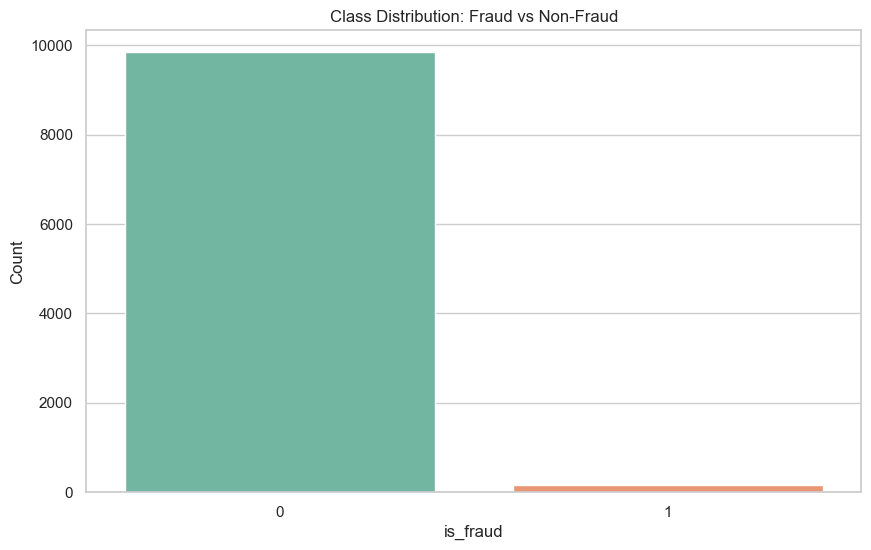

In [4]:

# Fraud class imbalance visualization
ax = sns.countplot(data=df, x=TARGET_COL, palette="Set2")
ax.set_title("Class Distribution: Fraud vs Non-Fraud")
ax.set_xlabel("is_fraud")
ax.set_ylabel("Count")
plt.show()


NameError: name 'df' is not defined

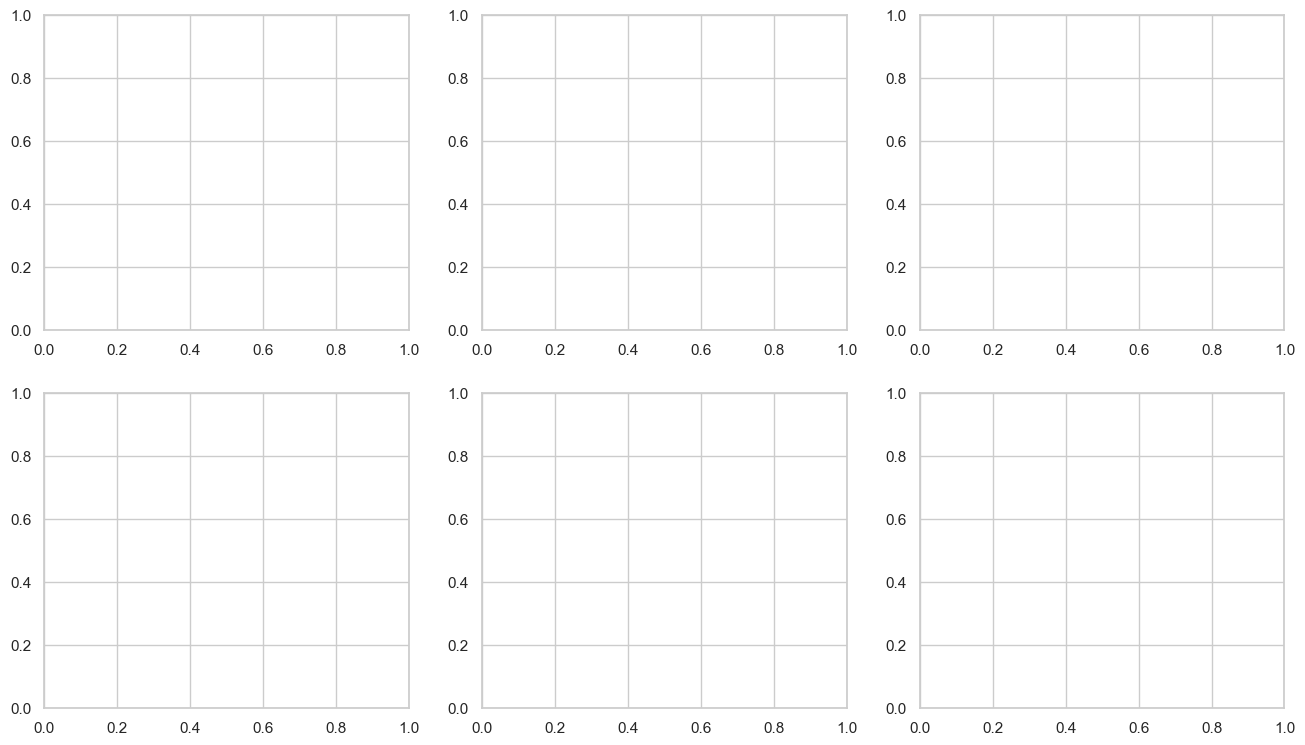

In [2]:

# Numeric feature distributions
num_cols = [
    "amount",
    "transaction_hour",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue=TARGET_COL, bins=30, kde=True, element="step", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


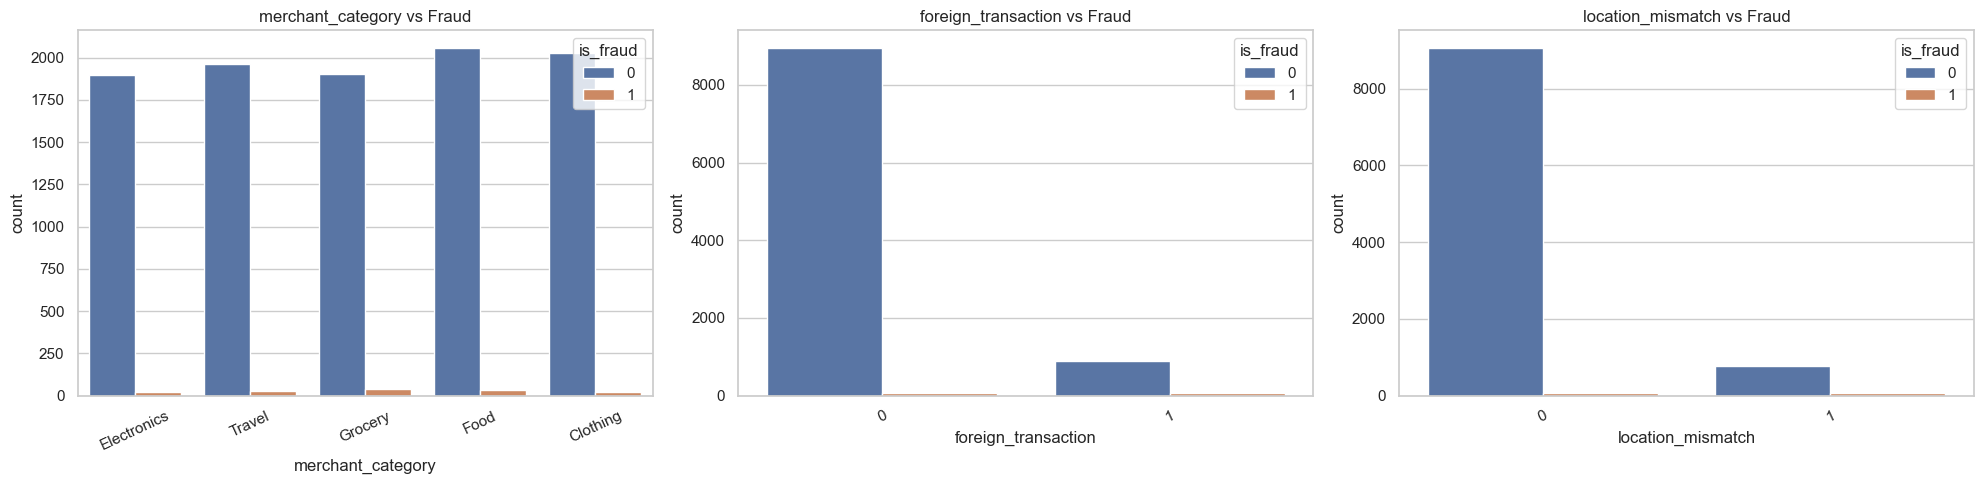

In [6]:

# Categorical and binary risk indicators by fraud
cat_cols = ["merchant_category", "foreign_transaction", "location_mismatch"]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, col in zip(axes, cat_cols):
    sns.countplot(data=df, x=col, hue=TARGET_COL, ax=ax)
    ax.set_title(f"{col} vs Fraud")
    ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


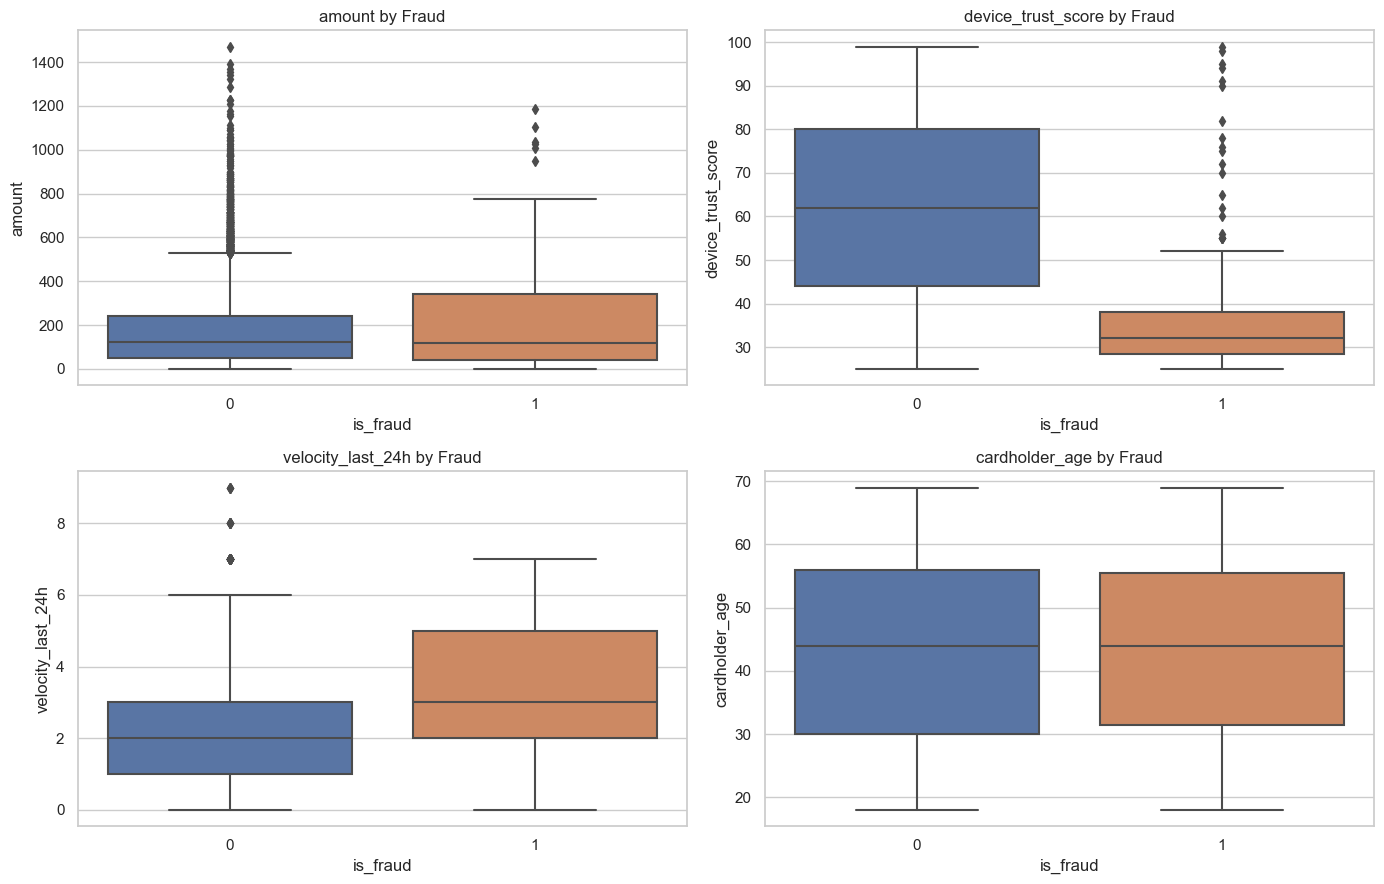

In [7]:

# Boxplots for fraud separation insight
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_cols = ["amount", "device_trust_score", "velocity_last_24h", "cardholder_age"]
for ax, col in zip(axes.ravel(), plot_cols):
    sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax)
    ax.set_title(f"{col} by Fraud")

plt.tight_layout()
plt.show()


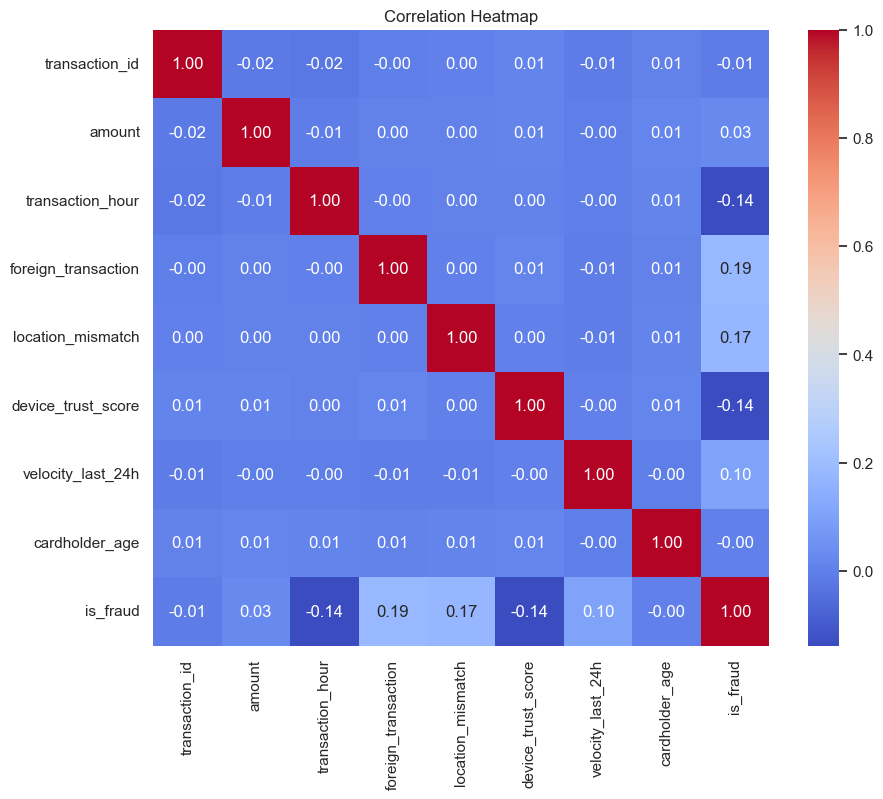

: 

In [ ]:

# Correlation heatmap (numeric features)
num_df = df.select_dtypes(include=["number"])
plt.figure(figsize=(10, 8))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()



## Model Diagnostics (Saved Artifact)

Uses the trained model from `model.pkl` and evaluates on the same deterministic split logic as training scripts.


In [ ]:
import sys
import numpy as np

MODEL_READY = False
MODEL_ERROR = None
model = None
model_name = "unavailable"
threshold = 0.5
X_test = None
y_test = None
y_prob = None
y_pred = None

# Compatibility shim: models saved with NumPy 2.x may reference numpy._core
if "numpy._core" not in sys.modules:
    try:
        import numpy._core  # noqa: F401
    except ModuleNotFoundError:
        sys.modules["numpy._core"] = np.core

try:
    artifact = joblib.load(PROJECT_ROOT / "model.pkl")
except Exception as e:
    MODEL_ERROR = repr(e)
    print("Primary model load failed:", MODEL_ERROR)

    # Fallback: train a compatible local model in the current kernel
    try:
        from src.train import train as train_pipeline
    except ModuleNotFoundError:
        from train import train as train_pipeline

    fallback_path = PROJECT_ROOT / "model_compat.pkl"
    print("Attempting fallback training for current kernel ->", fallback_path)
    try:
        best_name, _ = train_pipeline(
            data_path=str(PROJECT_ROOT / "data" / "credit_card_fraud_10k.csv"),
            output_model_path=str(fallback_path),
            target_col=TARGET_COL,
            random_state=42,
            use_smote=True,
        )
        artifact = joblib.load(fallback_path)
        print("Fallback model ready:", best_name)
    except Exception as e2:
        MODEL_ERROR = f"Primary: {MODEL_ERROR} | Fallback failed: {repr(e2)}"
        print("Fallback training failed:", repr(e2))
        artifact = None

if artifact is not None:
    model = artifact["model"]
    model_name = artifact.get("model_name", "unknown")
    threshold = float(artifact.get("threshold", 0.5))

    split = split_data(
        df,
        target_col=TARGET_COL,
        drop_cols=["transaction_id"] if "transaction_id" in df.columns else [],
        test_size=0.2,
        random_state=42,
    )

    X_test = split.X_test
    y_test = split.y_test.to_numpy()
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    MODEL_READY = True

    print("Model:", model_name)
    print("Threshold:", threshold)
    print("Test size:", len(y_test))
else:
    print("Model diagnostics are skipped. Reason:", MODEL_ERROR)
    print("Use kernel 'Python (fraud-venv)' for full parity with trained artifact.")

In [3]:
if MODEL_READY:
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
else:
    print(f"Skipped: model not loaded. Reason: {MODEL_ERROR}")

NameError: name 'MODEL_READY' is not defined

In [ ]:
if MODEL_READY:
    
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()
else:
    print(f"Skipped: model not loaded. Reason: {MODEL_ERROR}")

Skipped: model not loaded.


In [ ]:
if MODEL_READY:
    
    # Precision-Recall curve
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.4f}")
    plt.title("Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend(loc="lower left")
    plt.show()
else:
    print(f"Skipped: model not loaded. Reason: {MODEL_ERROR}")

Skipped: model not loaded.



## Threshold vs Cost Analysis

Reads the exported table from `data/cost_analysis.csv`.


In [ ]:

cost_df = pd.read_csv(PROJECT_ROOT / "data" / "cost_analysis.csv")
print("Rows:", len(cost_df))
cost_df.head()


In [ ]:

# Cost, precision, recall, and F1 across thresholds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(data=cost_df, x="threshold", y="total_cost", ax=axes[0, 0], color="crimson")
axes[0, 0].set_title("Total Cost vs Threshold")

sns.lineplot(data=cost_df, x="threshold", y="precision", ax=axes[0, 1], color="teal")
axes[0, 1].set_title("Precision vs Threshold")

sns.lineplot(data=cost_df, x="threshold", y="recall", ax=axes[1, 0], color="orange")
axes[1, 0].set_title("Recall vs Threshold")

sns.lineplot(data=cost_df, x="threshold", y="f1", ax=axes[1, 1], color="purple")
axes[1, 1].set_title("F1 vs Threshold")

for ax in axes.ravel():
    ax.axvline(threshold, ls="--", color="black", alpha=0.7)

plt.tight_layout()
plt.show()


In [ ]:

# Best threshold row by minimum total cost
best = cost_df.loc[cost_df["total_cost"].idxmin()]
best
